In [4]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
features_df = pd.read_csv('data/features_df_v1.csv')
bp_feature = pd.read_csv('data/waka_with_imputed_bp.csv')
features_merged_df = pd.merge(
    features_df,
    bp_feature[['CID', 'bp_value']], on='CID', how='left')
features_merged_df = features_merged_df.loc[:, 'CID':]
mX = features_merged_df.iloc[:,1:].to_numpy()

In [8]:
data_df = pd.read_csv('data/waka_dragon_merged.csv')
vY = data_df['Imax'].astype(float).values


In [14]:
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

xgb_basic = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

vY_pred_xgb = cross_val_predict(
    xgb_basic,
    mX,
    vY,
    cv=cv,
    n_jobs=-1
)

xgb_mae = mean_absolute_error(vY, vY_pred_xgb)
xgb_r2 = r2_score(vY, vY_pred_xgb)

print(f"XGBoost MAE: {xgb_mae:.2f}")
print(f"XGBoost R2: {xgb_r2:.2f}")

XGBoost MAE: 8.52
XGBoost R2: 0.52


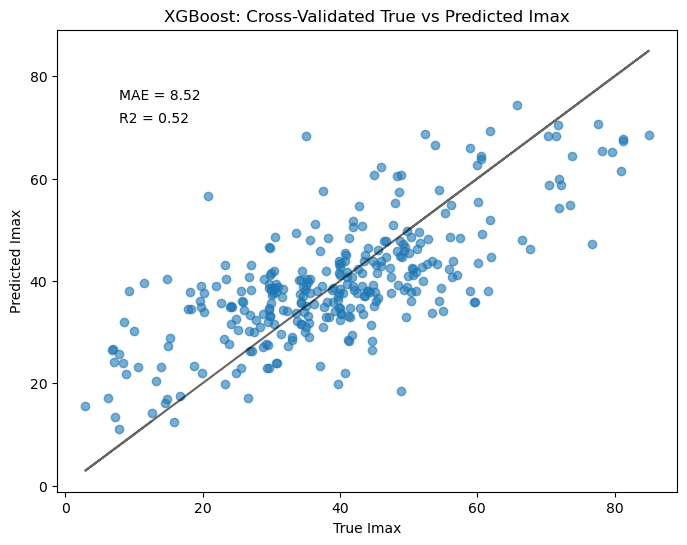

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(vY, vY_pred_xgb, alpha=0.6)
plt.plot(vY, vY, color="black", alpha=0.6)
plt.xlabel("True Imax")
plt.ylabel("Predicted Imax")
plt.title("XGBoost: Cross-Validated True vs Predicted Imax")
plt.text(0.1, 0.85, f"MAE = {xgb_mae:.2f}", transform=plt.gca().transAxes)
plt.text(0.1, 0.80, f"R2 = {xgb_r2:.2f}", transform=plt.gca().transAxes)
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

cv_tune = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gs_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv_tune,
    n_jobs=-1,
    verbose=2,
    refit=True
)

gs_xgb.fit(mX, vY)

print(f"Best XGBoost CV MAE: {-gs_xgb.best_score_:.2f}")
print("Best parameters:")
print(gs_xgb.best_params_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best XGBoost CV MAE: 8.44
Best parameters:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


In [18]:
feature_names = features_merged_df.loc[:, "f1_mass_PC1":].columns

gs_xgb.best_estimator_.fit(mX, vY)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": gs_xgb.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
8,f6_volume_PC1,0.117675
10,f7_surface_shape_Mor_PC2,0.101605
54,bp_value,0.056072
50,f14_spdiam_PC1,0.045287
0,f1_mass_PC1,0.037728
28,f10_geometry_topology_PC1,0.036545
46,f13_p_vsa_logp_PC2,0.033249
49,f13_p_vsa_logp_PC5,0.032020
16,f8_surface_shape_RDF_PC1,0.028571
30,f10_geometry_topology_PC3,0.025663


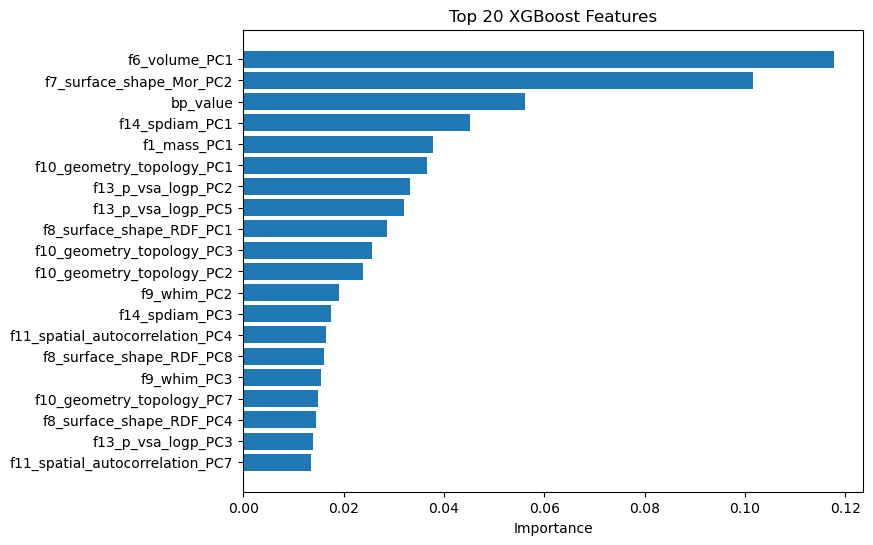

In [19]:
top20 = importance_df.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top20["feature"][::-1], top20["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 XGBoost Features")
plt.show()

In [20]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X_all=